## From TT optimized models, can simulate and visualize different spiking neural datasets

* need to match these w the parameters in real-life experiments

In [9]:
TT_NODE = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True"
TT_gNODE = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep/max_epochs=1500_weight_decay=1.00E-06_learning_rate=2.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=64_delta_t=1.00E-02_alpha=1.00E-01_leak=True"
TT_nGRU = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250413_PClicks_NoisyGRU_final2/max_epochs=1500_weight_decay=1.00E-04_learning_rate=1.00E-04_noise=5.00E-04_seed=0_latent_size=128_delta_t=1.00E-02_latent_ic_var=5.00E-03_l2_wt=1.00E-05_noise_level=5.00E-03"

node_sim_data = "/scratch/gpfs/ad2002/content/datasets/dt/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True"

# currently have heldin_50_heldout_10_obs_noise_pseudoPoisson_dispersion_1.0_seed_0.h5

In [10]:
from ctd.task_modeling.simulator.neural_simulator import NeuralDataSimulator
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# always runs with seed=0
def simulate(tt_model_path="/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True",
             tt_dataset_path="/scratch/gpfs/ad2002/content/datasets/dt",
             tt_run_tag="20250407_PC_NODE_grid_final",
             tune_name="max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True",
             
             embed_dict={
                 "fr_scaling": 0.5,  # Scaling factor for firing rates
                 "rect_func": "softplus"  # Nonlinearity for rectification (options: "exp", "sigmoid", "softplus")
             },
             noise_dict={
                 "obs_noise": "poisson",  # Observation noise model (options: "poisson", "pseudoPoisson")
                 "dispersion": 0.1  # Dispersion parameter for pseudo-Poisson noise
             },
             neuron_dict={
                 "n_neurons_heldin": 300,
                 "n_neurons_heldout": 50,
             },
             trim_inds=None,
            ):
    
    """Simulate and save a spiking dataset from the latents of a task-trained model
    
    Returns:
        data (np.ndarray): the spiking dataset (n_trials, timesteps, total_neurons)
        inputs (np.ndarray): TT model inputs, correspond to the data
        activity (np.ndarray): rectified neural rates
        latents (np.ndarray): TT model latents
    """
    
    # load model
    with open(tt_model_path + "/model.pkl", "rb") as f:
        task_trained_model = pickle.load(f)
            
    # load datamodule
    with open(tt_model_path + "/datamodule_sim.pkl", "rb") as f:
        datamodule = pickle.load(f)
        datamodule.prepare_data()
        datamodule.setup()
    
    # create simulator object
    simulator = NeuralDataSimulator(neuron_dict, embed_dict, noise_dict, trim_inds)
    
    return simulator.simulate_neural_data(task_trained_model, datamodule, tt_run_tag, tune_name, tt_dataset_path, seed=0)


def raster_plot(spike_data, input_data, n_trials_to_plot=None, neurons_to_plot=3, figsize=(18, 12)):
    """
    Create raster plots of neuronal activity with corresponding input signals.
    Trials are plotted in a single column.
    
    Parameters:
    -----------
    spike_data : numpy.ndarray
        Array of shape (n_trials, timesteps, n_neurons) containing spike data
        where 1 indicates a spike and 0 indicates no spike.
    input_data : numpy.ndarray
        Array of shape (n_trials, timesteps, input_dim) containing input signals.
    n_trials_to_plot : int or None
        Number of trials to plot. If None, all trials are plotted.
    neurons_to_plot : int
        Number of neurons to plot (from the beginning of the array)
    figsize : tuple
        Figure size (width, height) in inches
    """
    n_trials, timesteps, n_neurons = spike_data.shape
    _, _, input_dim = input_data.shape
    
    # Handle how many trials to plot
    if n_trials_to_plot is None:
        n_trials_to_plot = n_trials
    else:
        n_trials_to_plot = min(n_trials_to_plot, n_trials)
    
    # Handle how many neurons to plot
    neurons_to_plot = min(neurons_to_plot, n_neurons)
    
    # Create figure with GridSpec for flexible subplot layout
    fig = plt.figure(figsize=figsize)
    
    # Create a grid with 2*n_trials_to_plot rows (2 for each trial - spikes and inputs)
    # and 1 column
    gs = gridspec.GridSpec(2*n_trials_to_plot, 1, height_ratios=[3, 2] * n_trials_to_plot)
    
    # Plot each trial
    for trial_idx in range(n_trials_to_plot):
        # Calculate the position in the grid for this trial
        spike_row = 2 * trial_idx
        input_row = 2 * trial_idx + 1
        
        # Create subplot for spike data
        ax_spikes = fig.add_subplot(gs[spike_row, 0])
        
        # Extract spike data for the current trial, limited to the selected neurons
        trial_spike_data = spike_data[trial_idx, :, :neurons_to_plot]
        
        # For each neuron
        for neuron_idx in range(neurons_to_plot):
            # Find the spike times for this neuron
            spike_times = np.where(trial_spike_data[:, neuron_idx] > 0)[0]
            
            # Plot spikes as dots
            ax_spikes.scatter(spike_times, np.ones_like(spike_times) * neuron_idx, 
                           marker='.', color='black', s=10)
        
        # Set title for the spike plot
        ax_spikes.set_title(f'Trial {trial_idx+1}')
        
        # Set y labels for all subplots
        ax_spikes.set_ylabel('Neurons')
        
        # Set limits
        ax_spikes.set_xlim(0, timesteps)
        ax_spikes.set_ylim(-0.5, neurons_to_plot - 0.5)
        
        # Show proper timestamps on x-axis
        # Only show x tick labels for the input plots of each trial
        ax_spikes.set_xticklabels([])
        
        # Create subplot for input data
        ax_inputs = fig.add_subplot(gs[input_row, 0], sharex=ax_spikes)
        
        # Extract input data for the current trial
        trial_input_data = input_data[trial_idx]
        click_times_fix = np.where(trial_input_data[:,0] > 0.5)[0]
        click_times_left = np.where(trial_input_data[:,1] > 0.5)[0]
        click_times_right = np.where(trial_input_data[:,2] > 0.5)[0]                                                    
        
        ax_inputs.scatter(click_times_left, -0.25*np.ones_like(click_times_left), 
                           marker='|', color='blue', s=10)
        ax_inputs.scatter(click_times_right, 0.25*np.ones_like(click_times_right), 
                           marker='|', color='red', s=10)
        
        ax_inputs.set_xlim(0, timesteps)
        ax_inputs.set_ylim(-0.5, 0.5)
        
        # Set y label for all input subplots
        ax_inputs.set_ylabel('Clicks')
        
        # Show proper timestamps on x-axis
#         # Only show complete x-axis labels on the bottom-most subplot
#         if trial_idx < n_trials_to_plot - 1:
#             ax_inputs.set_xticklabels([])
#         else:
#             # For the last subplot, show the full x-axis with timestamps
#             ax_inputs.set_xlabel('Timesteps ($\Delta t=10~ms$)')
            
        # Add legend only to the first subplot to avoid repetition
        if trial_idx == 0 and input_dim <= 5:
            ax_inputs.legend(loc='best', fontsize='small')
    
    plt.tight_layout()
    
    return fig

In [11]:
# NODE
# softplus, poisson, dispersion=1.0 for best fit (overdispersion=0) in Luo et al (fano=1.0 for Pois, in theory)

for i,j in [[150,150], [200,100], [250,50], [280,20]]:
    spike_data_node, inputs_node, activity_node, latents_node = simulate(
                 embed_dict={
                     "fr_scaling": 1.0,  # mean to variance ratio for the embeddings
                     "rect_func": "softplus"  # Nonlinearity for rectification (options: "exp", "sigmoid", "softplus")
                 },
                 noise_dict={
                     "obs_noise": "poisson",  # Observation noise model (options: "poisson", "pseudoPoisson")
                     "dispersion": 1.0  # =1 for Poisson
                 },
                 neuron_dict={
                     "n_neurons_heldin": i,
                     "n_neurons_heldout": j,
                 },)

In [12]:
# gnode
TT_gNODE = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep/max_epochs=1500_weight_decay=1.00E-06_learning_rate=2.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=64_delta_t=1.00E-02_alpha=1.00E-01_leak=True"
#TT_gNODE = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.20E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=1.00E-01_leak=True"         
            
for i,j in [[150,150], [200,100], [250,50], [280,20]]:
    spike_data_gnode, inputs_gnode, activity_gnode, latents_gnode = simulate(
                tt_model_path=TT_gNODE,
                tt_dataset_path="/scratch/gpfs/ad2002/content/datasets/dt",
                tt_run_tag="20250412_PC_gNODE_sweep",
                tune_name="max_epochs=1500_weight_decay=1.00E-06_learning_rate=2.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=64_delta_t=1.00E-02_alpha=1.00E-01_leak=True",
    
                 embed_dict={
                     "fr_scaling": 1.0,  # mean to variance ratio for the embeddings
                     "rect_func": "softplus"  # Nonlinearity for rectification (options: "exp", "sigmoid", "softplus")
                 },
                 noise_dict={
                     "obs_noise": "poisson",  # Observation noise model (options: "poisson", "pseudoPoisson")
                     "dispersion": 1.0  # =1 for Poisson
                 },
                 neuron_dict={
                     "n_neurons_heldin": i,
                     "n_neurons_heldout": j,
                 },)

In [13]:
# nGRU
for i,j in [[150,150], [200,100], [250,50], [280,20]]:
    spike_data_gru, inputs_gru, activity_gru, latents_gru = simulate(
                tt_model_path=TT_nGRU,
                tt_dataset_path="/scratch/gpfs/ad2002/content/datasets/dt",
                tt_run_tag="20250413_PClicks_NoisyGRU_final2",
                tune_name="max_epochs=1500_weight_decay=1.00E-04_learning_rate=1.00E-04_noise=5.00E-04_seed=0_latent_size=128_delta_t=1.00E-02_latent_ic_var=5.00E-03_l2_wt=1.00E-05_noise_level=5.00E-03",
    
                 embed_dict={
                     "fr_scaling": 1.0,  # mean to variance ratio for the embeddings
                     "rect_func": "softplus"  # Nonlinearity for rectification (options: "exp", "sigmoid", "softplus")
                 },
                 noise_dict={
                     "obs_noise": "poisson",  # Observation noise model (options: "poisson", "pseudoPoisson")
                     "dispersion": 1.0  # =1 for Poisson
                 },
                 neuron_dict={
                     "n_neurons_heldin": i,
                     "n_neurons_heldout": j,
                 },)

Using matplotlib backend: module://matplotlib_inline.backend_inline


/tmp/ipykernel_3448845/2532239739.py:199: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_spikes.set_xticklabels([f'{int(x*dt_ms)}' for x in xticks])
/tmp/ipykernel_3448845/2532239739.py:199: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_spikes.set_xticklabels([f'{int(x*dt_ms)}' for x in xticks])
/tmp/ipykernel_3448845/2532239739.py:199: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_spikes.set_xticklabels([f'{int(x*dt_ms)}' for x in xticks])


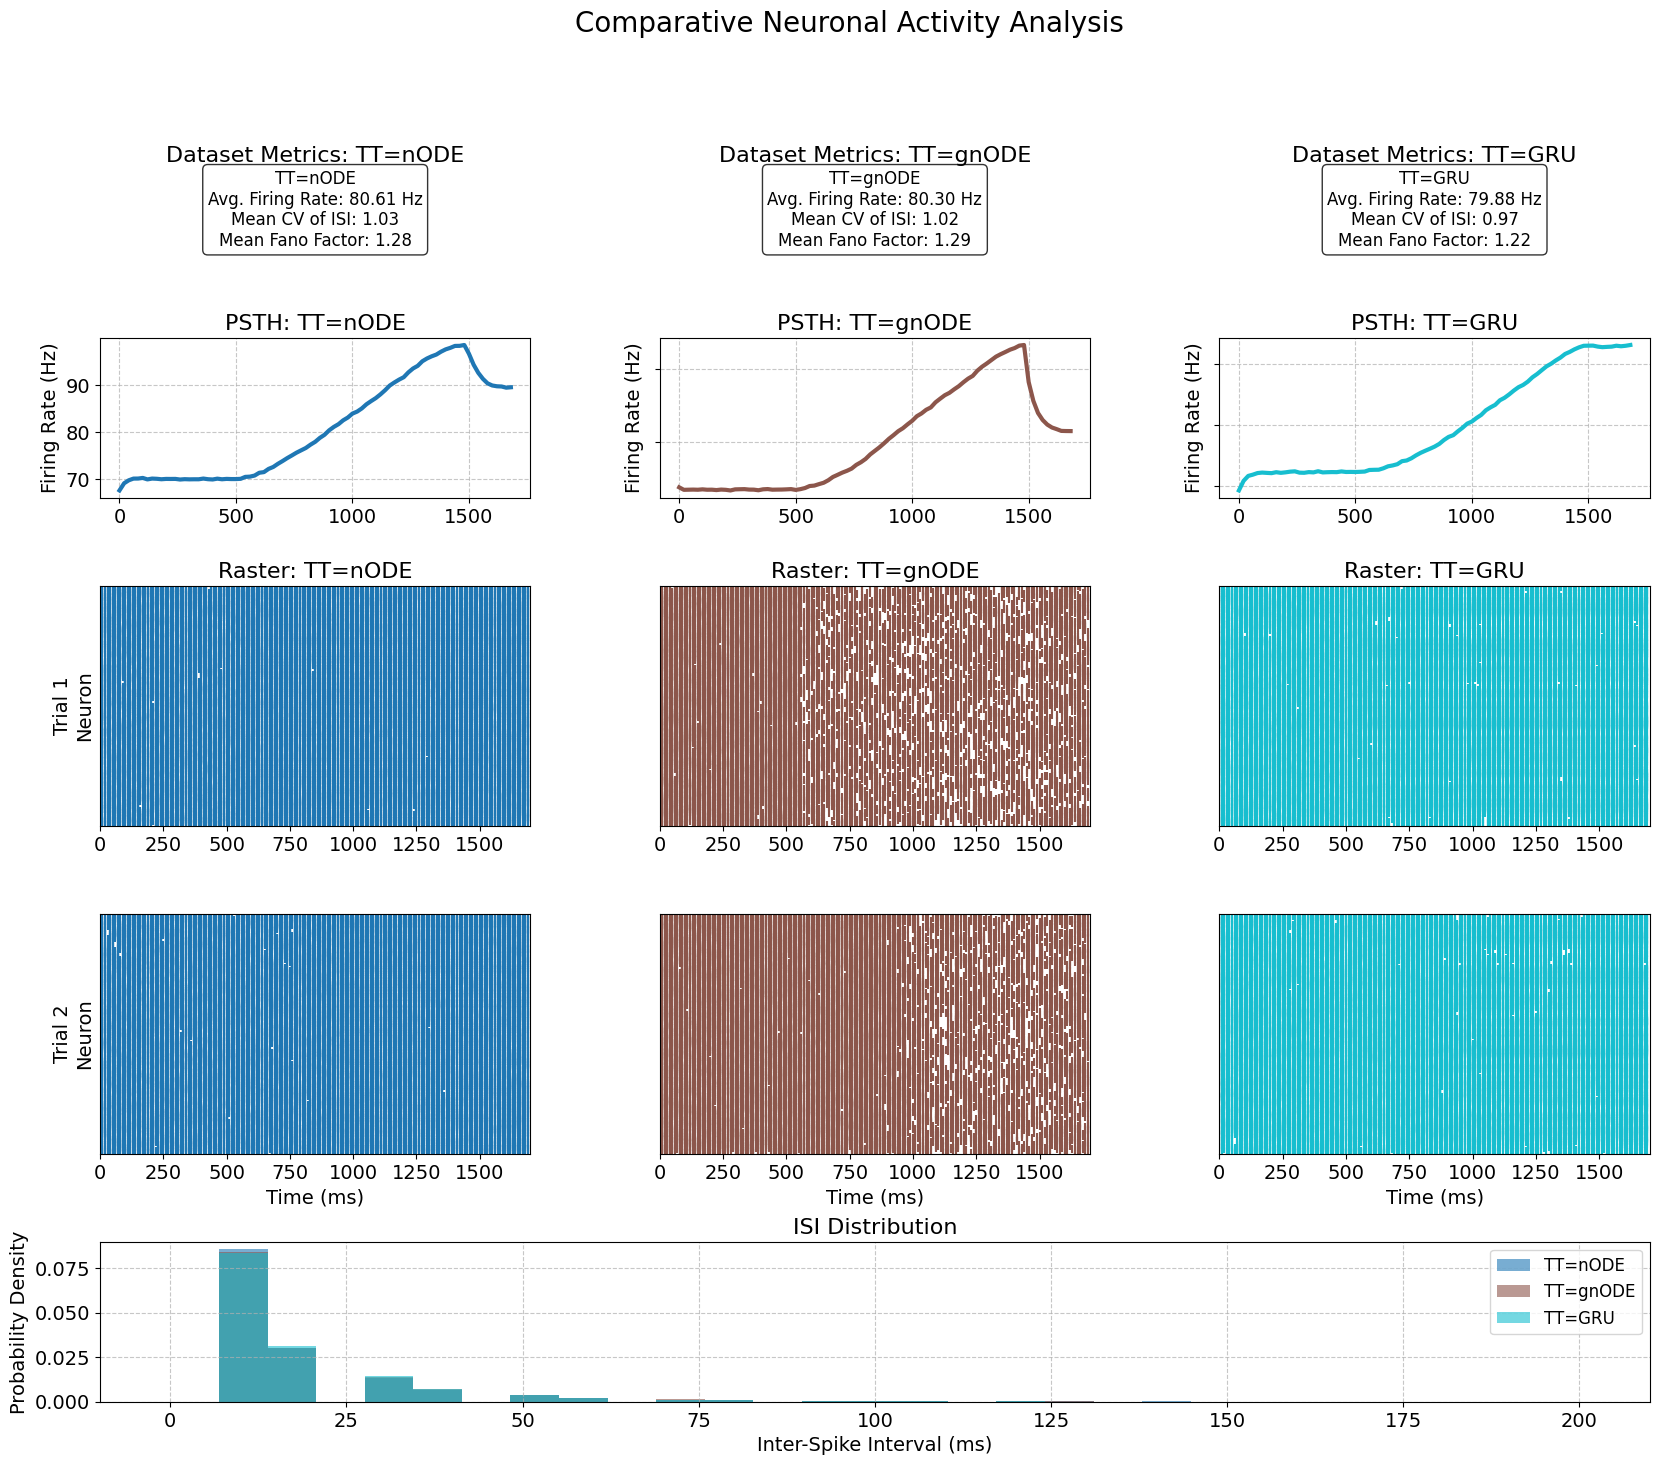

In [38]:
# Comprehensive comparison with all analysis
%matplotlib 
fig2 = compare_raster_plots([spike_data_node, spike_data_gnode, spike_data_gru],
                    [inputs_node, inputs_gnode, inputs_gru],
                    labels=['TT=nODE', 'TT=gnODE', 'TT=GRU'],
                     neurons_to_plot=300,
                     n_trials_to_plot=2)

# this i did NOT use


# all neurons have the same sudden change for ONE trial
# it varies across trials

# ex below for 10 neurons from first 3 trials (as many trials as input trials in TT)

In [37]:
def compare_raster_plots(spike_data_list, input_data_list, labels=None, 
                        n_trials_to_plot=10, neurons_to_plot=3, 
                        figsize=(20, 16), dt_ms=10, 
                        share_axes=True):
    """
    Create comparative raster plots of multiple neuronal activity datasets with corresponding
    PSTH (Peri-Stimulus Time Histogram) and ISI (Inter-Spike Interval) plots.
    
    Parameters:
    -----------
    spike_data_list : list of numpy.ndarray
        List of arrays, each with shape (n_trials, timesteps, n_neurons) containing spike data
    input_data_list : list of numpy.ndarray
        List of arrays, each with shape (n_trials, timesteps, input_dim) containing input signals
        (needed for time dimensions, but not plotted)
    labels : list of str or None
        Labels for each dataset (for legend and titles)
    n_trials_to_plot : int or None
        Number of trials to plot. If None, all trials are plotted.
    neurons_to_plot : int
        Number of neurons to plot (from the beginning of the array)
    figsize : tuple
        Figure size (width, height) in inches
    dt_ms : float
        Time bin size in milliseconds (for proper time axis scaling)
    share_axes : bool
        Whether to share axes across datasets for direct comparison
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    from matplotlib.ticker import MaxNLocator
    
    plt.rcParams.update({'font.size': 14})  # Increase default font size
    
    n_datasets = len(spike_data_list)
    if labels is None:
        labels = [f'Dataset {i+1}' for i in range(n_datasets)]
    elif len(labels) != n_datasets:
        raise ValueError("Length of labels must match length of spike_data_list")
    
    # Get basic shape information from first dataset
    n_trials, timesteps, n_neurons = spike_data_list[0].shape
    
    # Handle how many trials to plot
    if n_trials_to_plot is None:
        n_trials_to_plot = n_trials
    else:
        n_trials_to_plot = min(n_trials_to_plot, n_trials)
    
    # Handle how many neurons to plot
    neurons_to_plot = min(neurons_to_plot, n_neurons)
    
    # Reorganize layout: 
    # - First row: metrics for each dataset
    # - Second row: PSTH for all datasets
    # - Third row and beyond: raster plots for each trial
    # - Last row: ISI histograms for all datasets
    
    # Create figure with GridSpec for flexible subplot layout
    fig = plt.figure(figsize=figsize)
    
    # Set up GridSpec: Metrics + PSTH + Raster plots + ISI
    n_rows = 3 + n_trials_to_plot  # Metrics, PSTH, Raster plots (n_trials), ISI
    gs = gridspec.GridSpec(n_rows, n_datasets, figure=fig, 
                          height_ratios=[1, 2] + [3] * n_trials_to_plot + [2])
    
    # Color scheme for different datasets
    colors = plt.cm.tab10(np.linspace(0, 1, n_datasets))
    
    # Create shared axes if requested
    shared_raster_ax = None
    
    # Calculate metrics for each dataset
    for dataset_idx, spike_data in enumerate(spike_data_list):
        # Compute relevant metrics for this dataset
        avg_firing_rate = np.mean(spike_data) * (1000/dt_ms)  # Convert to Hz
        cv_isi_values = []
        
        # Calculate CV of ISI for each neuron
        for neuron_idx in range(neurons_to_plot):
            all_isi = []
            for trial_idx in range(n_trials):
                spike_times = np.where(spike_data[trial_idx, :, neuron_idx] > 0)[0] * dt_ms
                if len(spike_times) > 1:
                    isi = np.diff(spike_times)
                    all_isi.extend(isi)
            
            if len(all_isi) > 1:
                cv_isi = np.std(all_isi) / np.mean(all_isi) if np.mean(all_isi) > 0 else 0
                cv_isi_values.append(cv_isi)
        
        mean_cv_isi = np.mean(cv_isi_values) if cv_isi_values else 0
        
        # Fano factor calculation using time bins
        # We divide the recording into multiple time bins and calculate 
        # Fano factor for each, then average them
        bin_size = int(10/dt_ms)  # 50ms bins for spike count
        n_bins = timesteps // bin_size
        all_fano_factors = []
        
        for neuron_idx in range(neurons_to_plot):
            neuron_fano_values = []
            for bin_idx in range(n_bins):
                start = bin_idx * bin_size
                end = start + bin_size
                if end <= timesteps:
                    # Count spikes in this bin across all trials
                    bin_counts = np.sum(spike_data[:, start:end, neuron_idx], axis=1)
                    if np.mean(bin_counts) > 0:
                        bin_fano = np.var(bin_counts) / np.mean(bin_counts)
                        neuron_fano_values.append(bin_fano)
            
            if neuron_fano_values:
                # Average Fano factor across time bins for this neuron
                neuron_mean_fano = np.mean(neuron_fano_values)
                all_fano_factors.append(neuron_mean_fano)
        
        mean_fano = np.mean(all_fano_factors) if all_fano_factors else 0
        
        # Plot metrics
        ax_metrics = fig.add_subplot(gs[0, dataset_idx])
        metrics_text = (
            f"{labels[dataset_idx]}\n"
            f"Avg. Firing Rate: {avg_firing_rate:.2f} Hz\n"
            f"Mean CV of ISI: {mean_cv_isi:.2f}\n"
            f"Mean Fano Factor: {mean_fano:.2f}"
        )
        ax_metrics.text(0.5, 0.5, metrics_text, 
                      ha='center', va='center', 
                      bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                      fontsize=12)
        ax_metrics.set_title(f"Dataset Metrics: {labels[dataset_idx]}", fontsize=16)
        ax_metrics.axis('off')  # Hide axes for text box
        
        # Plot PSTH for this dataset in the second row
        ax_psth = fig.add_subplot(gs[1, dataset_idx])
        
        # Calculate PSTH for this dataset
        psth_bin_size = int(20/dt_ms)  # 20 ms bins
        n_bins = timesteps // psth_bin_size
        time_axis_psth = (np.arange(n_bins) * psth_bin_size) * dt_ms
        
        psth = np.zeros((n_bins, neurons_to_plot))
        for bin_idx in range(n_bins):
            start = bin_idx * psth_bin_size
            end = start + psth_bin_size
            if end <= timesteps:
                psth[bin_idx] = np.mean(spike_data[:, start:end, :neurons_to_plot], 
                                     axis=(0,1)) * (1000/dt_ms)
        
        # Plot average PSTH across neurons
        avg_psth = np.mean(psth, axis=1)
        ax_psth.plot(time_axis_psth, avg_psth, color=colors[dataset_idx], 
                   linewidth=3)
        
        ax_psth.set_ylabel('Firing Rate (Hz)', fontsize=14)
        ax_psth.set_title(f'PSTH: {labels[dataset_idx]}', fontsize=16)
        ax_psth.grid(True, linestyle='--', alpha=0.7)
        # Only add x label for the last row
        if dataset_idx == 0:
            ax_psth.set_ylabel('Firing Rate (Hz)', fontsize=14)
        else:
            ax_psth.set_yticklabels([])
        
        # Plot raster plots for each trial
        for trial_idx in range(n_trials_to_plot):
            row_offset = 2 + trial_idx  # After metrics and PSTH rows
            
            # Create subplot for spike data (raster plot)
            if share_axes and shared_raster_ax is not None and (dataset_idx > 0 or trial_idx > 0):
                ax_spikes = fig.add_subplot(gs[row_offset, dataset_idx], 
                                          sharex=shared_raster_ax, sharey=shared_raster_ax)
            else:
                ax_spikes = fig.add_subplot(gs[row_offset, dataset_idx])
                if dataset_idx == 0 and trial_idx == 0 and share_axes:
                    shared_raster_ax = ax_spikes
            
            # Plot spike raster
            for neuron_idx in range(neurons_to_plot):
                spike_times = np.where(spike_data[trial_idx, :, neuron_idx] > 0)[0]
                ax_spikes.scatter(spike_times, [neuron_idx] * len(spike_times), 
                               marker='|', color=colors[dataset_idx], s=30)
            
            # Configure raster plot aesthetics
            ax_spikes.set_ylim(-0.5, neurons_to_plot - 0.5)
            ax_spikes.set_xlim(0, timesteps)
            
            # Add y-axis label only for the leftmost column
            if dataset_idx == 0:
                ax_spikes.set_ylabel(f'Trial {trial_idx+1}\nNeuron', fontsize=14)
            else:
                ax_spikes.set_yticks([])
            
            # Add x-axis label only for the bottom row
            if trial_idx == n_trials_to_plot - 1:
                ax_spikes.set_xlabel('Time (ms)', fontsize=14)
                xticks = ax_spikes.get_xticks()
                ax_spikes.set_xticklabels([f'{int(x*dt_ms)}' for x in xticks])
            else:
                ax_spikes.set_xticklabels([])
            
            # Add title only for the top row
            if trial_idx == 0:
                ax_spikes.set_title(f'Raster: {labels[dataset_idx]}', fontsize=16)
    
    # Plot ISI histograms in the last row
    row_offset = 2 + n_trials_to_plot  # After metrics, PSTH, and all raster plots
    
    # Single ISI plot combining all datasets
    ax_isi = fig.add_subplot(gs[row_offset, :])
    
    # Plot ISI histograms for each dataset
    bins = np.linspace(0, 200, 30)  # 0-200 ms bins with finer resolution
    
    for dataset_idx, spike_data in enumerate(spike_data_list):
        # Combine ISIs across all plotted neurons and trials
        all_isi = []
        
        for trial_idx in range(n_trials):
            for neuron_idx in range(neurons_to_plot):
                spike_times = np.where(spike_data[trial_idx, :, neuron_idx] > 0)[0] * dt_ms
                if len(spike_times) > 1:
                    all_isi.extend(np.diff(spike_times))
        
        if len(all_isi) > 0:
            ax_isi.hist(all_isi, bins=bins, alpha=0.6, 
                       color=colors[dataset_idx],
                       label=labels[dataset_idx], density=True)
    
    ax_isi.set_xlabel('Inter-Spike Interval (ms)', fontsize=14)
    ax_isi.set_ylabel('Probability Density', fontsize=14)
    ax_isi.set_title('ISI Distribution', fontsize=16)
    ax_isi.legend(loc='upper right', fontsize=12)
    ax_isi.xaxis.set_major_locator(MaxNLocator(nbins=10))  # Limit number of x-ticks
    ax_isi.grid(True, linestyle='--', alpha=0.7)
    
    # Add overall title
    plt.suptitle('Comparative Neuronal Activity Analysis', fontsize=20, y=0.98)
    
    # Adjust spacing between subplots
    plt.subplots_adjust(hspace=0.5, wspace=0.3)
    
    return fig